In [1]:
import os, re, numpy as np, pandas as pd, torch, pickle, warnings
from torch.utils.data import Dataset, DataLoader
from momentfm import MOMENTPipeline
from sklearn.metrics import roc_auc_score
from tqdm import tqdm

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message=".*IProgress.*")

DATA_DIR = "../TSB-AD-M"
WINDOW_SIZE = 512
TEST_STEP = 512
BATCH_SIZE = 16
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
USE_AMP = DEVICE.type == 'cuda'
print(f"Device: {DEVICE}, AMP: {USE_AMP}")

D:\Учёба\Учёба ВШЭ\2 семестр\Курсач\.venv1\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda, AMP: True


In [2]:
def parse_tr_len(fname):
    m = re.search(r'_tr_(\d+)_', fname)
    if m is None:
        raise ValueError(f"Cannot parse tr_len in {fname}")
    return int(m.group(1))


def get_dataset_name(fname):
    for ds in ["MSL", "MITDB", "GHL", "SMAP", "SMD", "LTDB", "SVDB", "SWaT", "TAO"]:
        if ds in fname:
            return ds
    raise ValueError(f"Unknown dataset for {fname}")


def point_adjustment(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=int)
    y_pred = np.asarray(y_pred, dtype=int)
    y_pred_pa = y_pred.copy()
    seg_start = None
    segments = []
    for i in range(len(y_true)):
        if y_true[i] == 1 and seg_start is None:
            seg_start = i
        elif y_true[i] == 0 and seg_start is not None:
            segments.append((seg_start, i))
            seg_start = None
    if seg_start is not None:
        segments.append((seg_start, len(y_true)))
    for s, e in segments:
        if np.any(y_pred[s:e] == 1):
            y_pred_pa[s:e] = 1
    return y_pred_pa

In [3]:
class SimpleTestDataset(Dataset):
    def __init__(self, data, window_size=512, step=256):
        self.data = data.astype(np.float32)
        self.window_size = window_size
        self.step = step
        self.indices = list(range(0, self.data.shape[0] - window_size + 1, step))

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        start = self.indices[idx]
        end = start + self.window_size
        x = self.data[start:end].T
        return torch.from_numpy(x), start

In [4]:
def aggregate_predictions(model, test_ds, total_len, batch_size=16):
    model.eval()
    C = test_ds.data.shape[1]
    sum_recon = np.zeros((total_len, C))
    sum_sq_diff = np.zeros(total_len)
    counts = np.zeros(total_len)

    loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)
    with torch.no_grad():
        for batch in tqdm(loader, desc="  Inference", leave=False):
            batch_x = batch[0].to(DEVICE)
            starts = batch[1].tolist()
            seq_len = batch_x.shape[-1]
            input_mask = torch.ones(batch_x.shape[0], seq_len, device=DEVICE)
            if USE_AMP:
                with torch.amp.autocast('cuda'):
                    recon = model(x_enc=batch_x, input_mask=input_mask).reconstruction
            else:
                recon = model(x_enc=batch_x, input_mask=input_mask).reconstruction
            recon = recon.cpu().numpy()
            for i, start in enumerate(starts):
                end_win = start + WINDOW_SIZE
                sum_recon[start:end_win] += recon[i].T
                error = np.mean((batch_x[i].cpu().numpy().T - recon[i].T) ** 2, axis=1)
                sum_sq_diff[start:end_win] += error
                counts[start:end_win] += 1

    recon_full = np.full((total_len, C), np.nan)
    scores = np.full(total_len, np.nan)
    valid = counts > 0
    recon_full[valid] = sum_recon[valid] / counts[valid, np.newaxis]
    scores[valid] = sum_sq_diff[valid] / counts[valid]
    recon_full = np.apply_along_axis(lambda c: np.interp(np.arange(total_len),
                                                         np.where(valid)[0], c[valid]), axis=0, arr=recon_full)
    scores = np.interp(np.arange(total_len), np.where(valid)[0], scores[valid])
    return recon_full, scores

In [5]:

model = MOMENTPipeline.from_pretrained(
    "AutonLab/MOMENT-1-large",
    model_kwargs={"task_name": "reconstruction"}
)
model.init()
model = model.to(DEVICE).float()
model.eval()

all_files = [f for f in os.listdir(DATA_DIR) if f.endswith('.csv') and 'TSB-AD-M' not in f]
print(f"Found {len(all_files)} CSV files.")

results_per_series = {}  # dataset -> list of metrics dicts
plot_data = {}  # dataset -> list of plot dicts (for later)

for fname in tqdm(all_files, desc="Processing files"):
    ds = get_dataset_name(fname)
    filepath = os.path.join(DATA_DIR, fname)
    df = pd.read_csv(filepath).dropna()
    tr_len = parse_tr_len(fname)
    data = df.iloc[:, :-1].values.astype(np.float32)
    labels = df['Label'].astype(np.int64).values

    test_data = data[tr_len:]
    test_labels = labels[tr_len:]

    if len(test_data) < WINDOW_SIZE:
        continue

    test_ds = SimpleTestDataset(test_data, WINDOW_SIZE, TEST_STEP)
    recon, scores = aggregate_predictions(model, test_ds, len(test_data), BATCH_SIZE)

    if len(np.unique(test_labels)) == 2:
        best_f1 = -1.0
        best_thr = 0.0
        for thr in np.unique(scores):
            preds = (scores >= thr).astype(int)
            tp = np.sum((test_labels == 1) & (preds == 1))
            fp = np.sum((test_labels == 0) & (preds == 1))
            fn = np.sum((test_labels == 1) & (preds == 0))
            prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
            rec = tp / (tp + fn) if (tp + fn) > 0 else 0.0
            f1 = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0.0
            if f1 > best_f1:
                best_f1 = f1
                best_thr = thr
        y_pred = (scores >= best_thr).astype(int)
    else:
        best_thr = 0.0
        y_pred = np.ones(len(scores), dtype=int)

    tp = np.sum((test_labels == 1) & (y_pred == 1))
    fp = np.sum((test_labels == 0) & (y_pred == 1))
    fn = np.sum((test_labels == 1) & (y_pred == 0))
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    rec = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0.0

    y_pred_pa = point_adjustment(test_labels, y_pred)
    tp_pa = np.sum((test_labels == 1) & (y_pred_pa == 1))
    fp_pa = np.sum((test_labels == 0) & (y_pred_pa == 1))
    fn_pa = np.sum((test_labels == 1) & (y_pred_pa == 0))
    prec_pa = tp_pa / (tp_pa + fp_pa) if (tp_pa + fp_pa) > 0 else 0.0
    rec_pa = tp_pa / (tp_pa + fn_pa) if (tp_pa + fn_pa) > 0 else 0.0
    f1_pa = 2 * prec_pa * rec_pa / (prec_pa + rec_pa) if (prec_pa + rec_pa) > 0 else 0.0

    roc_auc = roc_auc_score(test_labels, scores) if len(np.unique(test_labels)) == 2 else np.nan
    rmse = np.sqrt(np.mean((test_data - recon) ** 2))
    mae = np.mean(np.abs(test_data - recon))

    metrics_dict = {
        'f1': f1, 'precision': prec, 'recall': rec,
        'f1_pa': f1_pa, 'precision_pa': prec_pa, 'recall_pa': rec_pa,
        'roc_auc': roc_auc,
        'rmse': rmse, 'mae': mae,
        'threshold': best_thr,
    }
    results_per_series.setdefault(ds, []).append(metrics_dict)

    se = {
        'trues_full': test_data,
        'preds_full': recon,
        'labels_full': test_labels,
        'anomaly_scores': scores,
        'total_length': len(test_data),
        'optimal_threshold': best_thr,
        'file': fname
    }
    plot_data.setdefault(ds, []).append(se)



Found 154 CSV files.


Processing files: 100%|██████████| 154/154 [6:47:49<00:00, 158.89s/it]


In [6]:

dataset_summary = []
for ds in ["MSL", "MITDB", "GHL", "SMAP", "SMD", "LTDB", "SVDB", "SWaT", "TAO"]:
    if ds not in results_per_series:
        continue
    df = pd.DataFrame(results_per_series[ds])
    numeric = df.select_dtypes(include=[np.number])
    avg = numeric.mean()
    avg['dataset'] = ds
    dataset_summary.append(avg)

summary_df = pd.DataFrame(dataset_summary).set_index('dataset')
print("\n" + "=" * 80)
print("Pretrained Moment (no fine-tuning) – average metrics per dataset:")
print(summary_df)

with open("../pretrained_moment_results.pkl", "wb") as f:
    pickle.dump({
        'per_series': results_per_series,
        'per_dataset_avg': summary_df,
        'plot_data': plot_data
    }, f)
print("\nResults + plot data saved to pretrained_moment_results.pkl")


Pretrained Moment (no fine-tuning) – average metrics per dataset:
               f1  precision    recall     f1_pa  precision_pa  recall_pa  \
dataset                                                                     
MSL      0.303847   0.328525  0.595384  0.547155      0.435147   1.000000   
MITDB    0.088489   0.054195  0.477663  0.186827      0.110799   1.000000   
GHL      0.031640   0.017143  0.825276  0.080300      0.049808   0.987524   
SMAP     0.240759   0.256004  0.574893  0.447811      0.357543   1.000000   
SMD      0.309273   0.335858  0.420325  0.677334      0.558048   0.997306   
LTDB     0.286333   0.193538  0.737136  0.355573      0.235827   1.000000   
SVDB     0.147741   0.101131  0.332735  0.384257      0.250529   0.998715   
SWaT     0.267634   0.154898  1.000000  0.267634      0.154898   1.000000   
TAO      0.981405   0.998383  0.965033  0.982034      0.998384   0.966239   

          roc_auc       rmse        mae     threshold  
dataset                      

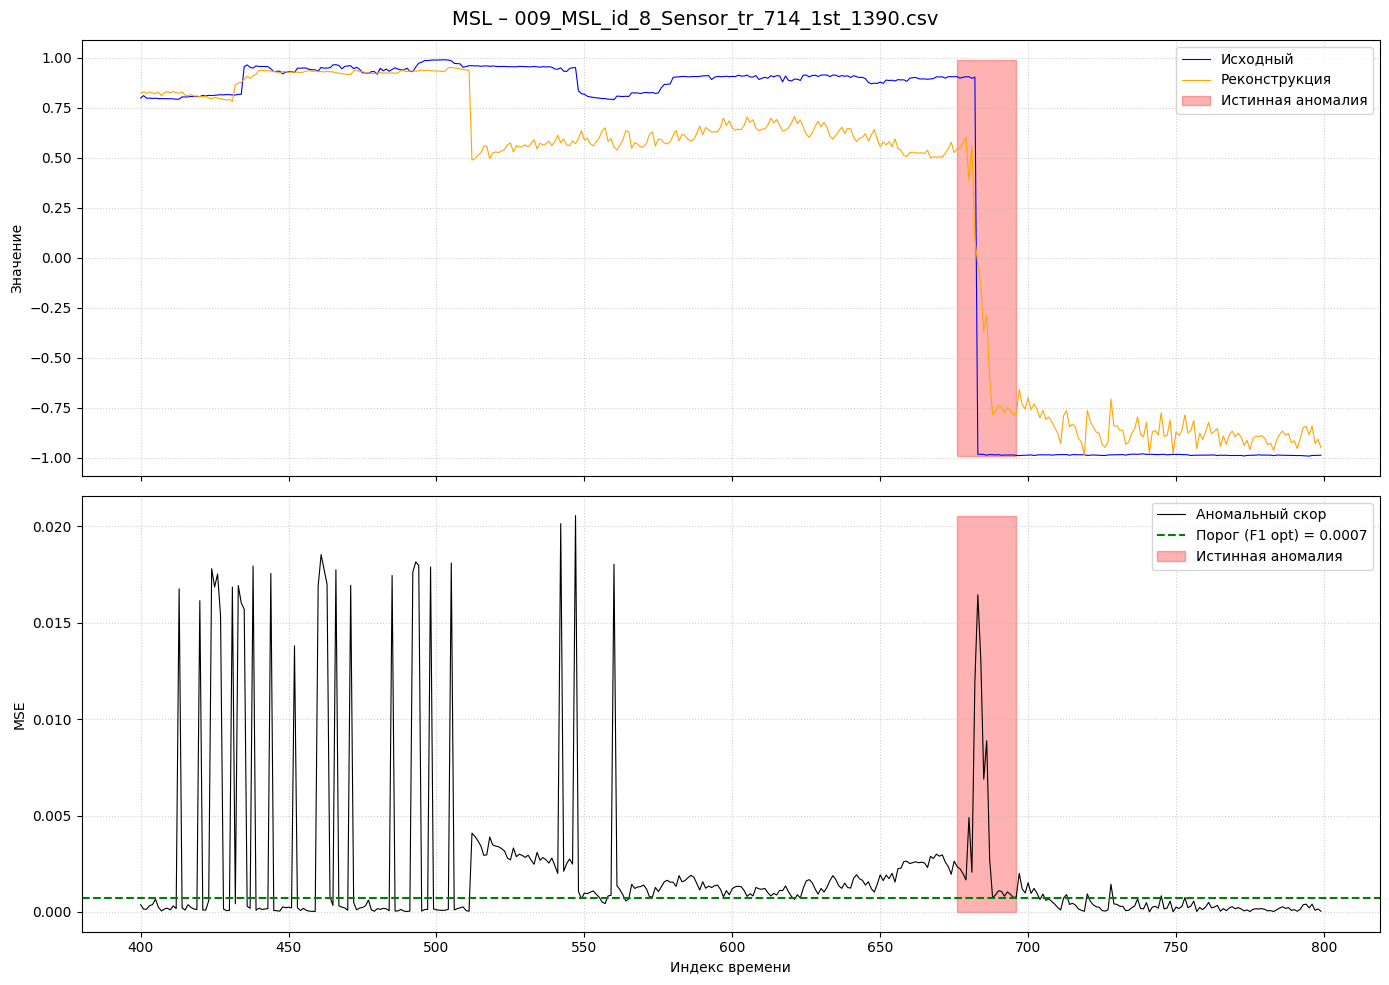

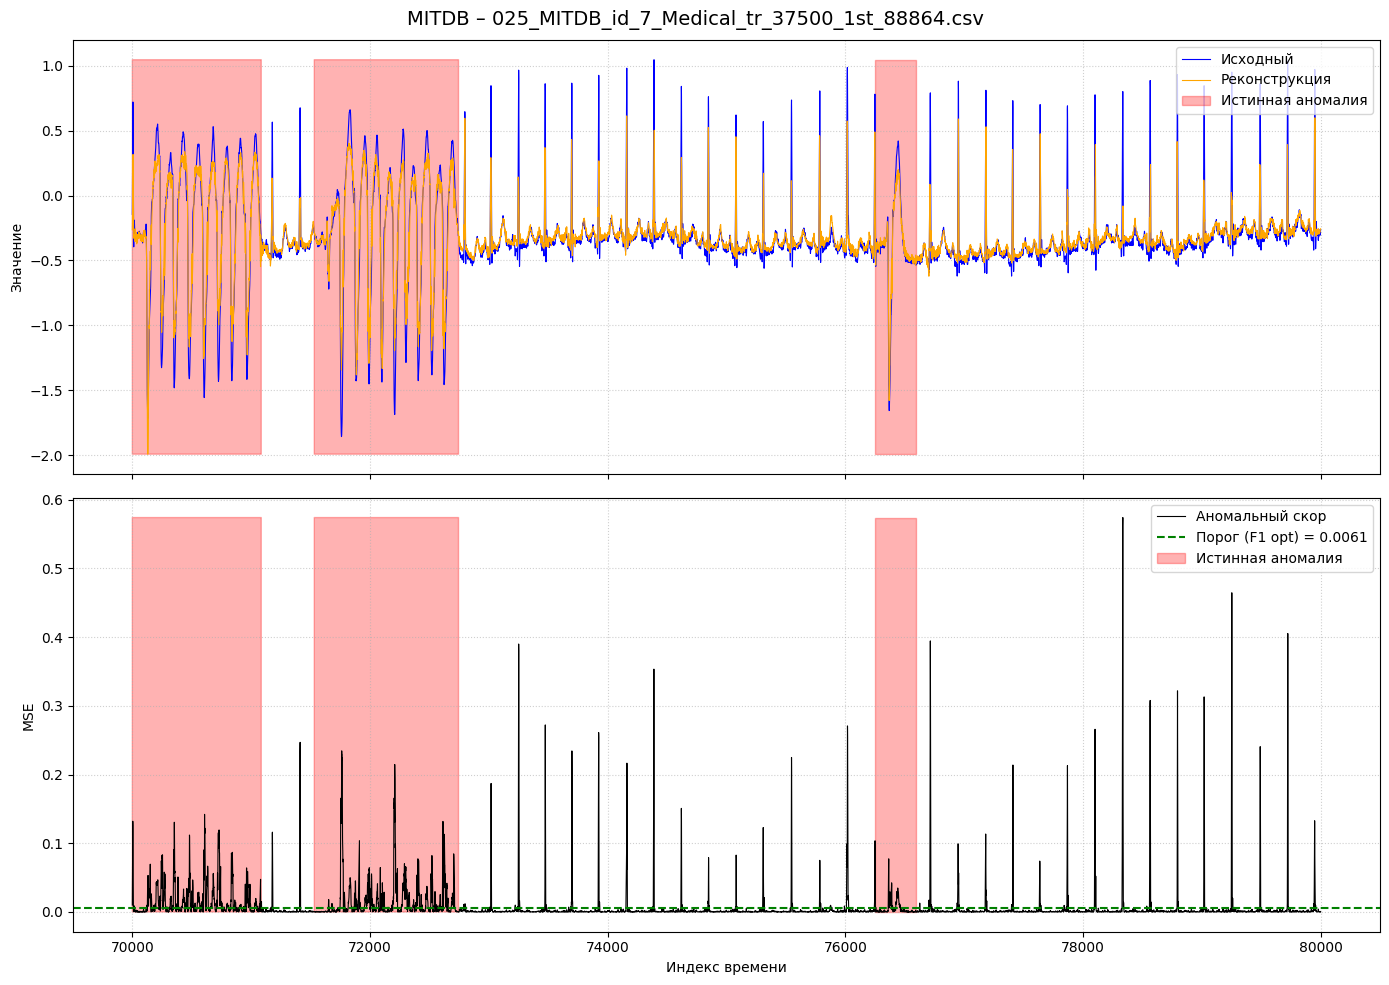

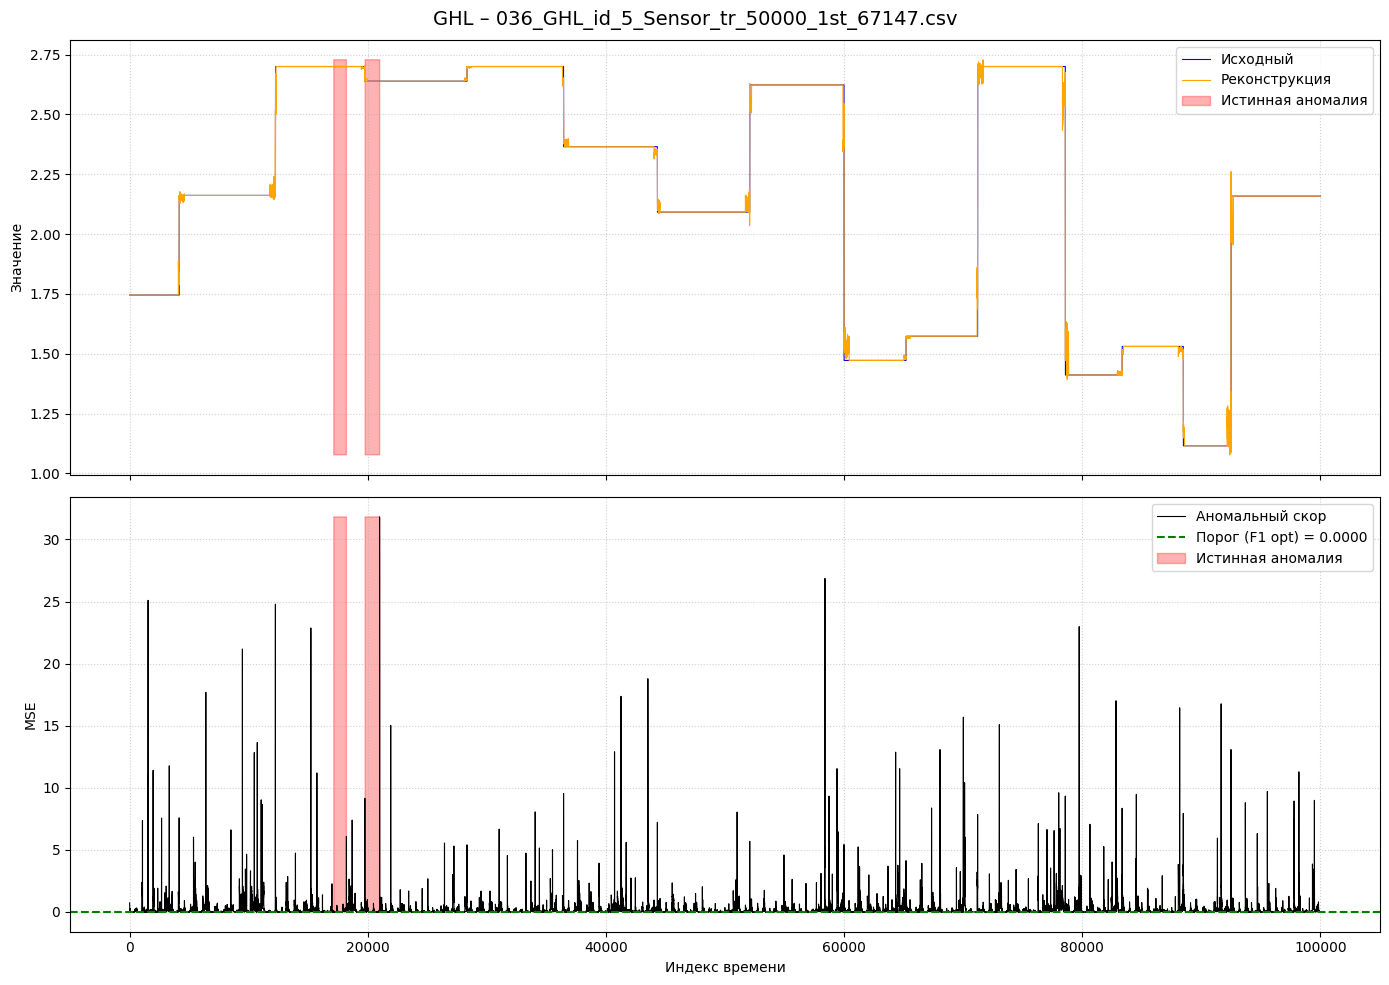

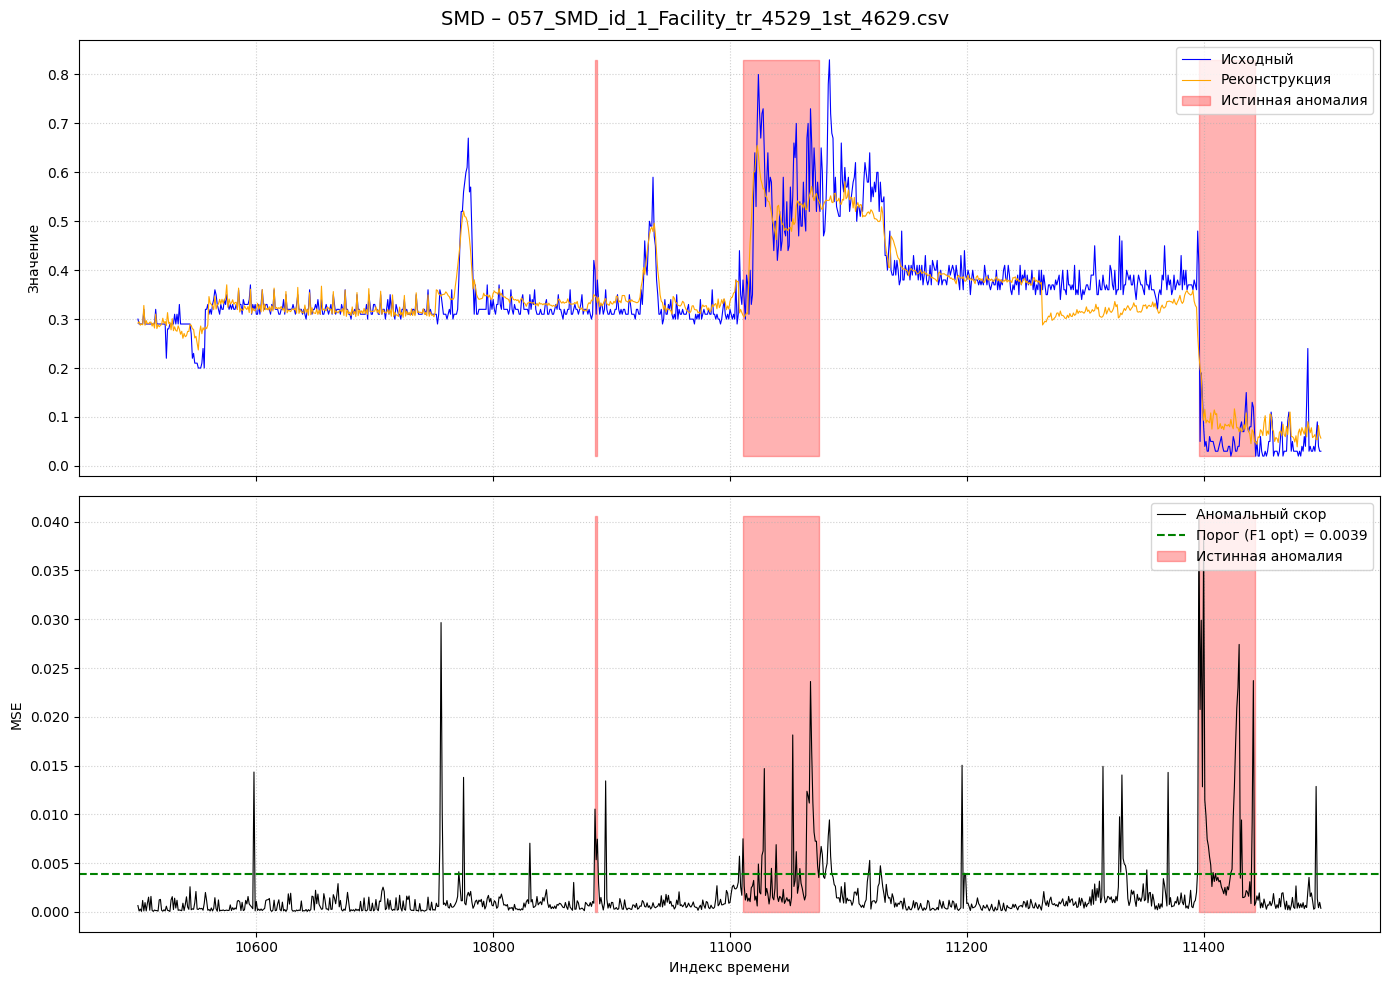

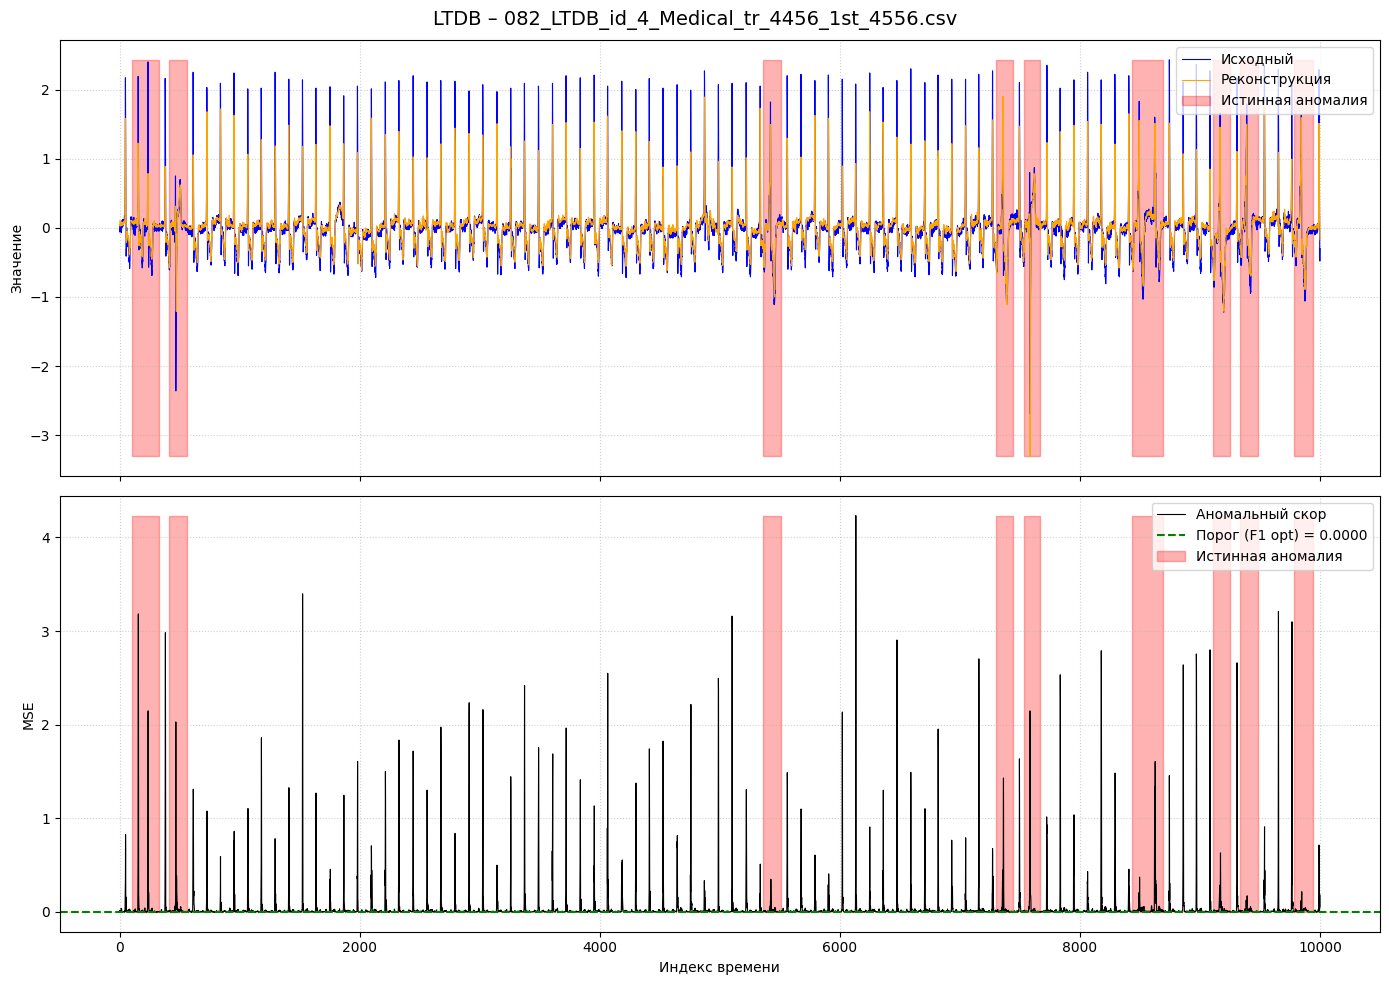

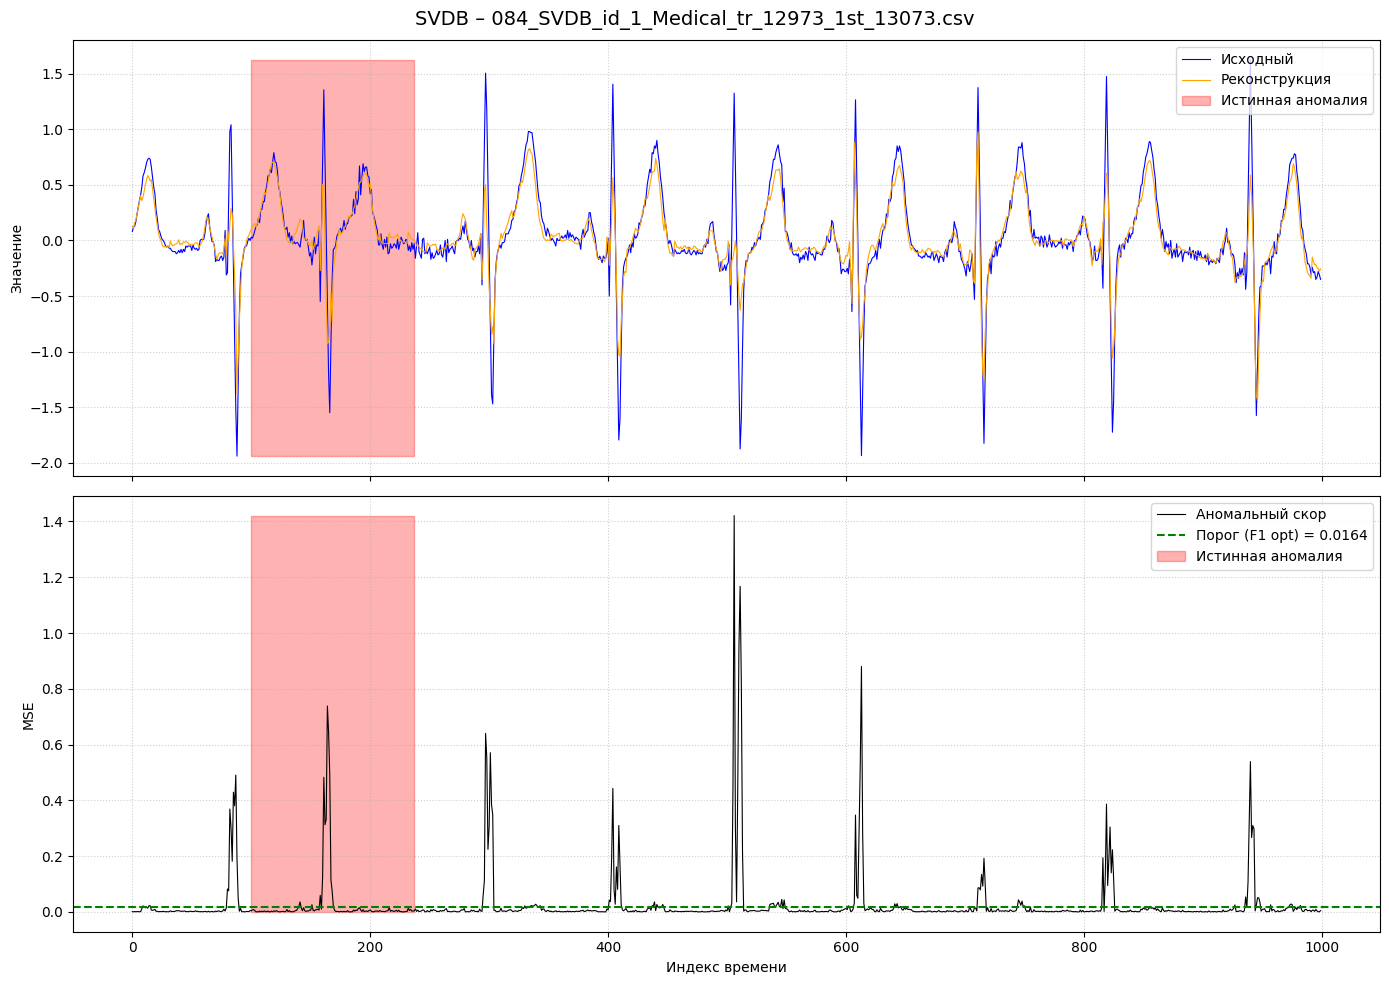

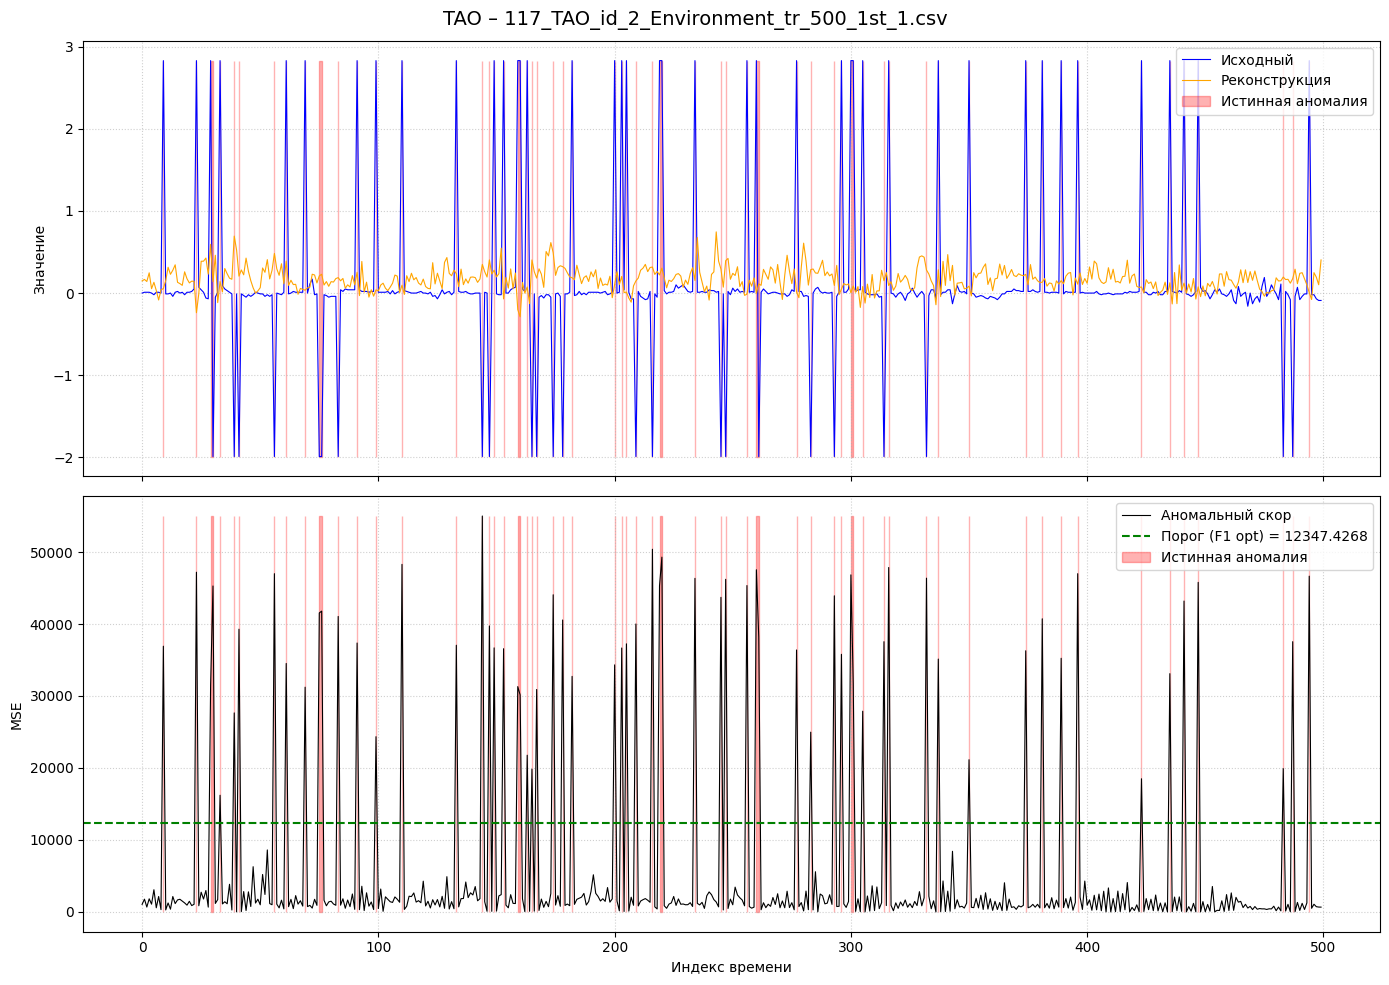

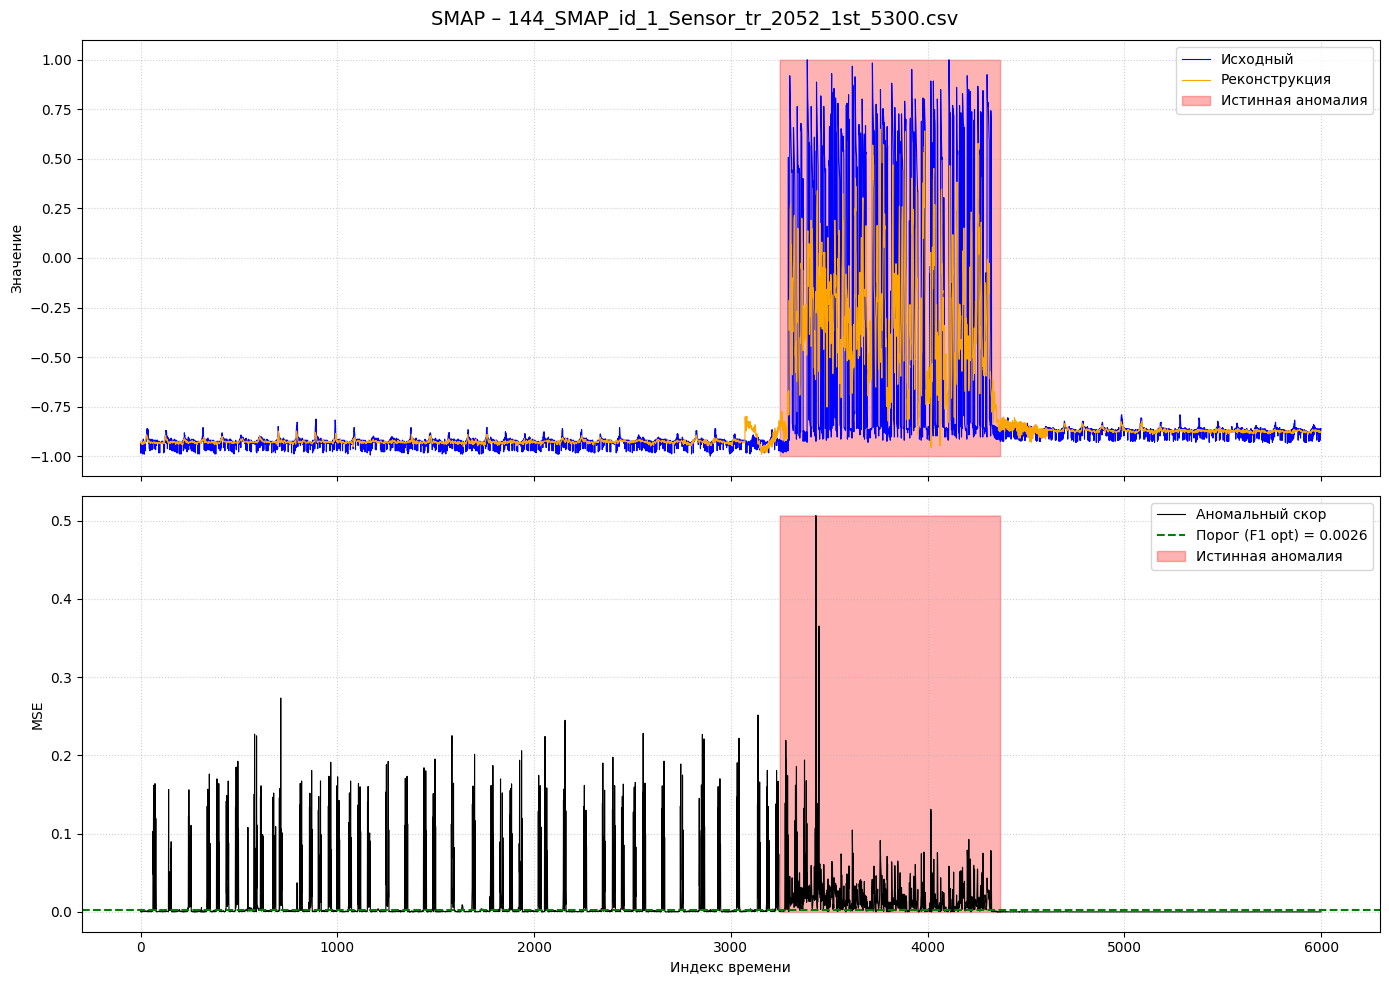

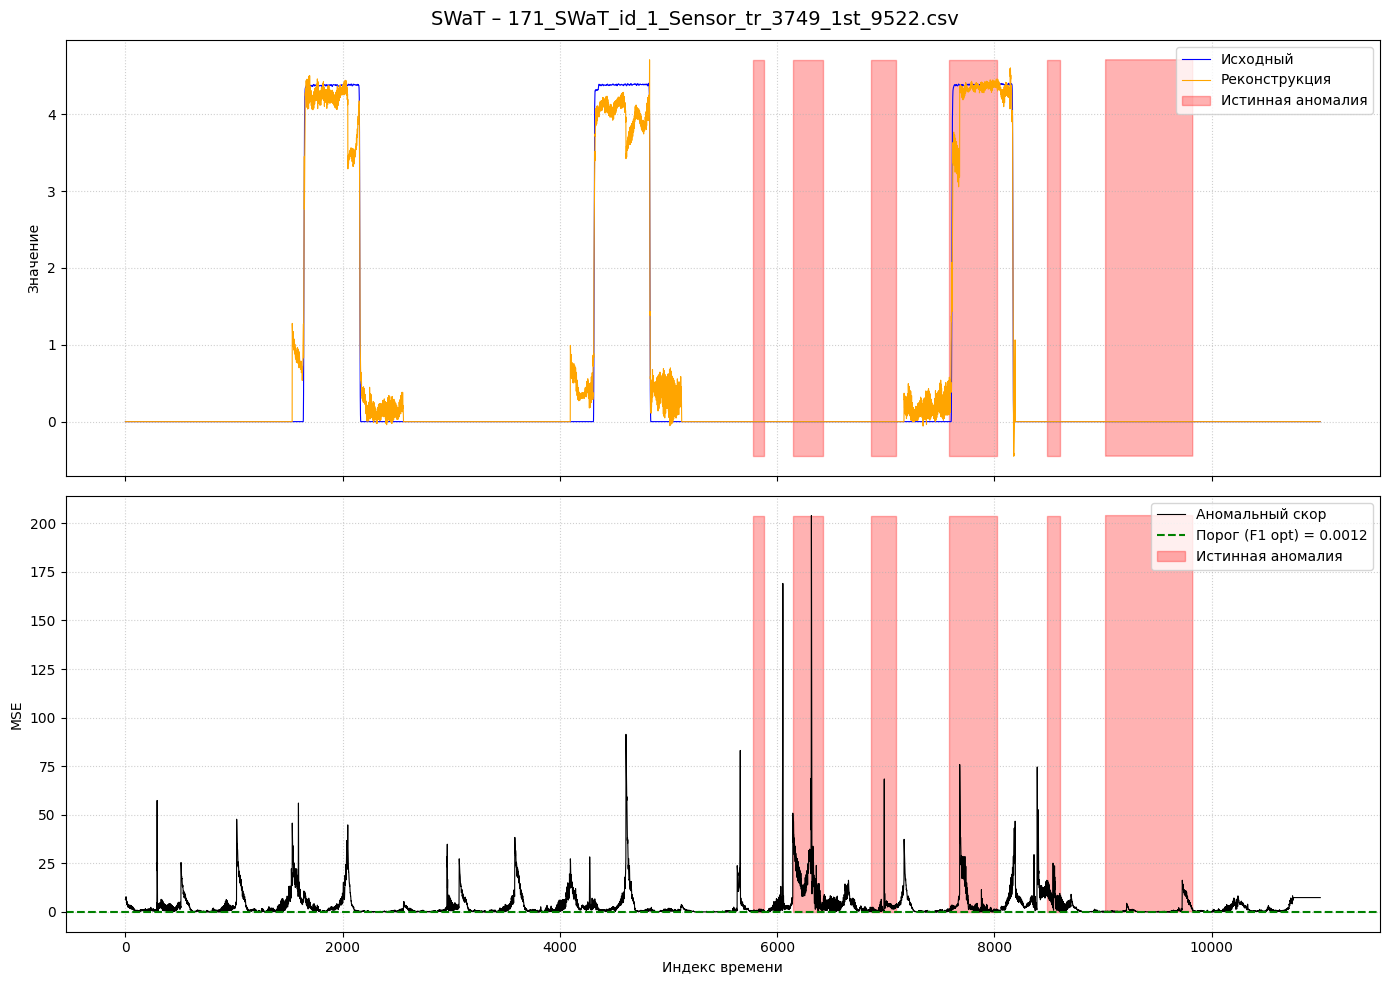

In [14]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import precision_recall_curve
import pickle

segments = {
    "MSL":
        {
            "start": 400,
            "end": 800,
        },
    "MITDB": {
            "start": 70_000,
            "end": 80_000,
    },
    "GHL": {
            "start": 0,
            "end": 100_000,
    },
    "SMAP":
        {
            "start": 0,
            "end": 6000,
        },
    "SMD":
        {
            "start": 10500,
            "end": 11500,
        },
    "LTDB": {
            "start": 0,
            "end": 10000,
    },
    "SVDB": {
            "start": 0,
            "end": 1000,
    },
    "SWaT": {
            "start": 0,
            "end": 11000,
    },
    "TAO": {
            "start": 0,
            "end": 500,
    },
}

with open("../pretrained_moment_results.pkl", "rb") as f:
    saved = pickle.load(f)
plot_data = saved['plot_data']

plt.style.use('default')
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'

window_display = 512

for ds_name, series_list in plot_data.items():
    chosen = None
    for se in series_list:
        if np.any(se['labels_full'] == 1):
            chosen = se
            break
    if chosen is None:
        chosen = series_list[0]

    if ds_name == "MSL":
        chosen = series_list[7]

    if ds_name == "MITDB":
        chosen = series_list[6]

    if ds_name == "GHL":
        chosen = series_list[4]

    if ds_name == "LTDB":
        chosen = series_list[3]

    if ds_name == "TAO":
        chosen = series_list[1]

    trues_full = chosen['trues_full']
    preds_full = chosen['preds_full']
    labels_full = chosen['labels_full']
    anomaly_scores = chosen['anomaly_scores']
    total_length = chosen['total_length']
    optimal_threshold = chosen['optimal_threshold']

    # anomaly_idx = np.where(labels_full == 1)[0]
    # if len(anomaly_idx) > 0:
    #     start = max(0, anomaly_idx[0] - window_display)
    #     end = min(total_length, anomaly_idx[-1] + window_display)
    # else:
    #     start, end = 0, min(2048, total_length)

    start, end = segments[ds_name]['start'], segments[ds_name]['end']

    time_axis = np.arange(start, end)

    fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
    fig.suptitle(f"{ds_name} – {chosen['file']}", fontsize=14)

    ax = axes[0]
    ax.plot(time_axis, trues_full[start:end, 0], 'b-', linewidth=0.8, label='Исходный')
    ax.plot(time_axis, preds_full[start:end, 0], 'orange', linewidth=0.8, label='Реконструкция')
    ax.fill_between(time_axis,
                    min(trues_full[start:end, 0].min(), preds_full[start:end, 0].min()),
                    max(trues_full[start:end, 0].max(), preds_full[start:end, 0].max()),
                    where=(labels_full[start:end] == 1), color='red', alpha=0.3, label='Истинная аномалия')
    ax.set_ylabel('Значение')
    ax.legend(loc='upper right')
    ax.grid(True, linestyle=':', alpha=0.6)

    ax = axes[1]
    ax.plot(time_axis, anomaly_scores[start:end], 'k-', linewidth=0.8, label='Аномальный скор')
    ax.axhline(y=optimal_threshold, color='green', linestyle='--', linewidth=1.5,
               label=f'Порог (F1 opt) = {optimal_threshold:.4f}')
    ax.fill_between(time_axis, 0, anomaly_scores[start:end].max(),
                    where=(labels_full[start:end] == 1), color='red', alpha=0.3, label='Истинная аномалия')
    ax.set_xlabel('Индекс времени')
    ax.set_ylabel('MSE')
    ax.legend(loc='upper right')
    ax.grid(True, linestyle=':', alpha=0.6)

    plt.tight_layout()
    plt.show()
    # plt.savefig(f"{ds_name}_reconstruction_plot.png", dpi=150)